# 산재 노동자 소득회복 궤적 분석
## 0. 환경 설정


In [1]:
!pip install python-calamine shap scikit-learn statsmodels seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# 한글 폰트 설정
# Mac: AppleGothic / Windows: Malgun Gothic
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
print("환경 설정 완료")

환경 설정 완료


## 1. 데이터 로드 및 전처리

**필요 파일**: `pswci2_05_wide.xlsx` (원본 패널)

**처리 흐름**: 5차 응답자 필터링 → RIRI 계산 → sqrt 변환 → df_lcga 구성

> RIRI = (근로소득 비중 × 3차 기준소득 / 생활임금) × (기준 CPI / 해당차수 CPI) × 100

In [3]:
# 통계청 소비자물가지수 (2020=100 기준)
CPI = {3: 97.4, 4: 102.5, 5: 107.7}

# 서울시 생활임금 (월, 만원)
LIVING_WAGE = {3: 197.8, 4: 208.5, 5: 219.8}

ALPHA    = 0.4
NAN_VALS = [9999998, 9999999]

In [4]:
df_wide = pd.read_excel("pswci2_05_wide.xlsx", engine="calamine")
df = df_wide[df_wide["p05"] == 1].copy()
print(f"5차 응답자: {len(df)}명")

5차 응답자: 2728명


In [5]:
# ============================================================
# 소득 변수 정제
#    대상: 개인소득총계(H0x003036), 근로소득(H0x002005), 휴업급여(H0x003001)
#    처리: 결측코드 → NaN, 단위 만원/연 → 만원/월(÷12)
# ============================================================

income_raw_cols = (
    [f'H0{w}003036' for w in range(1, 6)] +   # 개인소득총계
    [f'H0{w}002005' for w in range(1, 6)] +   # 근로소득
    [f'H0{w}003001' for w in range(1, 6)]     # 휴업급여
)

for col in income_raw_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').replace(NAN_VALS, np.nan)

# 월 단위 파생 변수 생성
for w in range(1, 6):
    for suffix in ['003036', '002005', '003001']:
        col_ann = f'H0{w}{suffix}'
        col_mon = f'H0{w}{suffix}_m'          # _m = monthly
        if col_ann in df.columns:
            df[col_mon] = df[col_ann] / 12

print("\n[차수별 개인소득총계 (월, 만원)]")
for w in range(1, 6):
    col = f'H0{w}003036_m'
    s = df[col].dropna()
    print(f"  {w}차: n={len(s)}, 평균={s.mean():.1f}, 중앙={s.median():.1f}")


[차수별 개인소득총계 (월, 만원)]
  1차: n=2728, 평균=336.5, 중앙=281.2
  2차: n=2654, 평균=204.9, 중앙=185.0
  3차: n=2650, 평균=202.6, 중앙=195.0
  4차: n=2693, 평균=211.5, 중앙=200.0
  5차: n=2728, 평균=207.0, 중앙=200.0


In [6]:
# ============================================================
# RIRI 계산 - 소득회복율
#    RIRI_w = (Q_irr_w × W_pre / LW_w) × (CPI_pre / CPI_w) × 100
#
#    Q_irr  = H0x002005_m / H0x003036_m   (근로소득 비중, 0~1 클리핑)
#    W_pre  = H03003036_m                 (3차 기준 월 소득)
#    LW_w   = 해당 차수 생활임금 (월, 만원)
#    post 차수: 3차(자기기준), 4차, 5차
# ============================================================

W_pre = df['H03003036_m']  # 3차 기준 월 소득

for w in [3, 4, 5]:
    total_m = df[f'H0{w}003036_m']
    earn_m  = df[f'H0{w}002005_m'].fillna(0)

    # Q_irr: 총소득 > 0인 경우만 계산
    q_irr = np.where(
        total_m.notna() & (total_m > 0),
        (earn_m / total_m).clip(0, 1),
        np.nan
    )

    riri = (q_irr * (W_pre / LIVING_WAGE[w])) * (CPI[3] / CPI[w]) * 100

    # 상위 1% 윈저라이징
    upper = np.nanpercentile(riri, 99)
    riri  = np.where(riri > upper, upper, riri)

    df[f'RIRI_w{w}'] = riri

    n_valid = (~np.isnan(riri)).sum()
    print(f"\nRIRI_w{w}: 유효={n_valid} | "
          f"평균={np.nanmean(riri):.1f} | 중앙={np.nanmedian(riri):.1f} | "
          f"≥100: {(riri>=100).sum()}명({np.nanmean(riri>=100)*100:.1f}%) | "
          f"<50: {(riri<50).sum()}명({np.nanmean(riri<50)*100:.1f}%)")



RIRI_w3: 유효=2464 | 평균=86.4 | 중앙=84.3 | ≥100: 1094명(40.1%) | <50: 859명(31.5%)

RIRI_w4: 유효=2490 | 평균=72.5 | 중앙=69.1 | ≥100: 825명(30.2%) | <50: 1049명(38.5%)

RIRI_w5: 유효=2501 | 평균=67.5 | 중앙=65.2 | ≥100: 764명(28.0%) | <50: 1067명(39.1%)


In [7]:
# ============================================================
# RIRI 3분류 레이블
#    2 = 완전회복 (RIRI ≥ 100)
#    1 = 부분회복 (50 ≤ RIRI < 100)
#    0 = 미회복   (RIRI < 50)
# ============================================================

def classify_riri(x):
    if pd.isna(x):   return np.nan
    elif x >= 100:   return 2
    elif x >= 50:    return 1
    else:            return 0

for w in [3, 4, 5]:
    df[f'RIRI_class_w{w}'] = df[f'RIRI_w{w}'].apply(classify_riri)
    dist  = df[f'RIRI_class_w{w}'].value_counts().sort_index()
    total = dist.sum()
    label = {0: '미회복', 1: '부분회복', 2: '완전회복'}
    print(f"{w}차: " + " | ".join(
        [f"{label[k]}={v}({v/total*100:.1f}%)" for k, v in dist.items()]))


3차: 미회복=859(34.9%) | 부분회복=511(20.7%) | 완전회복=1094(44.4%)
4차: 미회복=1049(42.1%) | 부분회복=616(24.7%) | 완전회복=825(33.1%)
5차: 미회복=1067(42.7%) | 부분회복=670(26.8%) | 완전회복=764(30.5%)


In [8]:
# ============================================================
# 장해등급 변수 처리
#    disa052  : 장해 유무 (1=있음, 2=없음)
#    disa0515 : 실제 등급 (1~14=유장해, 15=무장해)
#    → disa_class: 0=무장해, 1=중증(1~7급), 2=경증(8~14급)
# ============================================================

df['disa0515_num'] = pd.to_numeric(df['disa0515'], errors='coerce')

def classify_disability(g):
    if pd.isna(g) or g == 15:  return 0   # 무장해
    elif g <= 7:               return 1   # 중증
    else:                      return 2   # 경증

df['disa_class'] = df['disa0515_num'].apply(classify_disability)

dist_d = df['disa_class'].value_counts().sort_index()
print(f"\n장해등급: 무장해={dist_d.get(0,0)}, 중증(1~7급)={dist_d.get(1,0)}, "
      f"경증(8~14급)={dist_d.get(2,0)}")


장해등급: 무장해=521, 중증(1~7급)=290, 경증(8~14급)=1917


In [9]:
# ============================================================
# 경제활동상태 재코딩 (차수별)
#    emp0x2: 1=취업, 2=실업, 3=비경활
# ============================================================

for w in range(1, 6):
    col = f'emp0{w}2'
    if col in df.columns:
        df[f'empstat_w{w}'] = pd.to_numeric(df[col], errors='coerce')
        df.loc[~df[f'empstat_w{w}'].isin([1, 2, 3]), f'empstat_w{w}'] = np.nan

print("\n[차수별 경제활동상태]")
emp_label = {1: '취업', 2: '실업', 3: '비경활'}
for w in range(1, 6):
    col = f'empstat_w{w}'
    if col in df.columns:
        dist = df[col].value_counts().sort_index()
        print(f"  {w}차: " + ", ".join(
            [f"{emp_label.get(k,'?')}={v}" for k, v in dist.items()]))


[차수별 경제활동상태]
  1차: 취업=1698, 실업=1030
  2차: 취업=1833, 실업=821
  3차: 취업=1846, 실업=804
  4차: 취업=1910, 실업=783
  5차: 취업=1910, 실업=818


In [10]:
# ============================================================
# 심리·건강 변수 처리
#    자아존중감  G0x021001: 원척도 1(매우그렇다)~4(전혀그렇지않다) → 역코딩
#    생활만족도  G0x022007: 전반적 생활만족도
#    주관적건강  G0x005001: 1=매우나쁨 ~ 4=매우좋음
# ============================================================

for w in range(1, 6):
    ww = f'0{w}'
    # 자아존중감 역코딩 (높을수록 긍정)
    ec = f'G{ww}021001'
    if ec in df.columns:
        df[f'esteem_w{w}'] = 5 - pd.to_numeric(df[ec], errors='coerce')

    # 전반적 생활만족도
    sc = f'G{ww}022007'
    if sc in df.columns:
        df[f'lifesatis_w{w}'] = pd.to_numeric(df[sc], errors='coerce')

    # 주관적 건강상태
    hc = f'G{ww}005001'
    if hc in df.columns:
        df[f'health_w{w}'] = pd.to_numeric(df[hc], errors='coerce')

print("\n[5차 심리·건강 기초통계]")
for col, label in [('esteem_w5','자아존중감'), ('lifesatis_w5','생활만족도'), ('health_w5','주관적건강')]:
    if col in df.columns:
        s = df[col].dropna()
        print(f"  {label}: M={s.mean():.2f}, SD={s.std():.2f}, n={len(s)}")



[5차 심리·건강 기초통계]
  자아존중감: M=2.11, SD=0.70, n=2728
  생활만족도: M=2.62, SD=0.66, n=2728
  주관적건강: M=2.58, SD=0.67, n=2728


In [11]:
# ============================================================
# 재활서비스 이진화
#    jobservice05: 직업재활 (훈련/취업지원)
#    socservice05: 사회재활 (심리상담/취미)
# ============================================================

for col, new_col in [('jobservice05', 'job_rehab'), ('socservice05', 'soc_rehab')]:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce')
        df[new_col] = np.where(s.isna(), np.nan, (s >= 1).astype(float))

print(f"\n직업재활 이용: {df['job_rehab'].sum():.0f}명 | "
      f"사회재활 이용: {df['soc_rehab'].sum():.0f}명")



직업재활 이용: 435명 | 사회재활 이용: 489명


In [12]:
# ============================================================
# 최종 분석 데이터셋 구성 (LCGA 입력용)
# ============================================================

final_cols = [
    'pid',
    # Y 변수: RIRI (3~5차)
    'RIRI_w3', 'RIRI_w4', 'RIRI_w5',
    'RIRI_class_w3', 'RIRI_class_w4', 'RIRI_class_w5',
    # 원천 소득 (참고용)
    'H03003036', 'H04003036', 'H05003036',
    'H03002005', 'H04002005', 'H05002005',
    'H03003001', 'H04003001', 'H05003001',
    # 인구사회학적
    'gender', 'age054', 'edu05', 'area056',
    # 장해
    'disa052', 'disa0515_num', 'disa_class',
    # 재활서비스
    'service05', 'job_rehab', 'soc_rehab',
    # 경제활동상태 시계열
    'empstat_w1', 'empstat_w2', 'empstat_w3', 'empstat_w4', 'empstat_w5',
    # 자아존중감 시계열
    'esteem_w1', 'esteem_w2', 'esteem_w3', 'esteem_w4', 'esteem_w5',
    # 생활만족도 시계열
    'lifesatis_w1', 'lifesatis_w2', 'lifesatis_w3', 'lifesatis_w4', 'lifesatis_w5',
    # 주관적 건강상태 시계열
    'health_w1', 'health_w2', 'health_w3', 'health_w4', 'health_w5',
]

exist_cols = [c for c in final_cols if c in df.columns]
df_final   = df[exist_cols].copy()

# LCGA 대상: RIRI 3~5차 중 2개 시점 이상 유효
riri_obs = df_final[['RIRI_w3', 'RIRI_w4', 'RIRI_w5']].notna().sum(axis=1)
df_lcga  = df_final[riri_obs >= 2].copy()

print(f"\n최종 데이터: {df_final.shape}")
print(f"LCGA 분석 대상 (RIRI 2시점 이상): {len(df_lcga)}명")

# 결측 요약
print("\n[주요 변수 결측 요약]")
for col in ['RIRI_w3','RIRI_w4','RIRI_w5','disa_class','esteem_w1','lifesatis_w1']:
    if col in df_lcga.columns:
        miss = df_lcga[col].isna().sum()
        print(f"  {col}: 유효={df_lcga[col].notna().sum()}, 결측={miss}({miss/len(df_lcga)*100:.1f}%)")



최종 데이터: (2728, 46)
LCGA 분석 대상 (RIRI 2시점 이상): 2542명

[주요 변수 결측 요약]
  RIRI_w3: 유효=2436, 결측=106(4.2%)
  RIRI_w4: 유효=2482, 결측=60(2.4%)
  RIRI_w5: 유효=2472, 결측=70(2.8%)
  disa_class: 유효=2542, 결측=0(0.0%)
  esteem_w1: 유효=2542, 결측=0(0.0%)
  lifesatis_w1: 유효=2542, 결측=0(0.0%)


In [13]:
# df_lcga에 원본 변수 전체 포함시키기
riri_obs = df[['RIRI_w3', 'RIRI_w4', 'RIRI_w5']].notna().sum(axis=1)
df_lcga  = df[riri_obs >= 2].copy()   # df 전체 컬럼 유지

In [14]:
# sqrt 변환 적용
for w in [3, 4, 5]:
    col      = f'RIRI_w{w}'
    sqrt_col = f'sqrtRIRI_w{w}'
    df_lcga[sqrt_col] = np.sqrt(df_lcga[col])

# 확인
print("sqrt 변환 결과")
for w in [3, 4, 5]:
    s = df_lcga[f'sqrtRIRI_w{w}'].dropna()
    print(f"{w}차: 평균={s.mean():.2f}, SD={s.std():.2f}, 왜도={s.skew():.3f}")

sqrt 변환 결과
3차: 평균=7.80, SD=5.07, 왜도=-0.419
4차: 평균=6.96, SD=4.93, 왜도=-0.240
5차: 평균=6.77, SD=4.73, 왜도=-0.236


In [15]:
# ============================================================
# 결측 처리 - FIML 방식
# LCGA 자체가 FIML로 결측 처리하므로
# 여기서는 결측 플래그 변수만 생성해두고
# 실제 대체는 하지 않음 (원본 유지)
# ============================================================

print("=" * 55)
print("결측 처리 - FIML 방식 확정")
print("=" * 55)

# 결측 플래그 변수 생성 (나중에 민감도 분석용)
for w in [3, 4, 5]:
    df_lcga[f'miss_flag_w{w}'] = df_lcga[f'RIRI_w{w}'].isna().astype(int)

# 완전 관측 케이스 수 확인
complete = df_lcga[['RIRI_w3','RIRI_w4','RIRI_w5']].notna().all(axis=1)
print(f"\n  완전 관측 케이스:  {complete.sum()}명 ({complete.mean()*100:.1f}%)")
print(f"  부분 결측 케이스:  {(~complete).sum()}명 ({(~complete).mean()*100:.1f}%)")
print(f"\n  → LCGA에서 FIML로 자동 처리 예정")
print(f"  → 원본 RIRI 값 유지 (별도 대체 없음)")

결측 처리 - FIML 방식 확정

  완전 관측 케이스:  2306명 (90.7%)
  부분 결측 케이스:  236명 (9.3%)

  → LCGA에서 FIML로 자동 처리 예정
  → 원본 RIRI 값 유지 (별도 대체 없음)


**전처리 완료.**

`df_lcga`에 RIRI_w3/4/5, sqrtRIRI_w3/4/5, 공변량 전체 포함.

> 전처리 요약: 전체 3,294명 → 5차 응답자 2,728명 → RIRI 2차수 이상 유효 → df_lcga

## 2. LCGA 결과 병합

**필요 파일**: `lcga_class_k4.csv` (R에서 lcmm k=4 결과)

- 집단1: 만성미회복형
- 집단2: 하락취약형 ← 이 분석의 핵심 대상
- 집단3: 부분회복형
- 집단4: 안정고소득형

In [16]:
df_lcga.to_csv('pswci_riri_lcga.csv')

In [17]:
# ============================================================
# 1. R 결과 로드 및 병합
# ============================================================

# R에서 저장한 집단 할당 결과
df_class = pd.read_csv('lcga_class_k4.csv')
print("집단 할당 데이터:", df_class.shape)
print(df_class.head())
print("\n집단별 인원:")
print(df_class['class'].value_counts().sort_index())

# 기존 df_lcga에 집단 병합
df_lcga = df_lcga.drop(columns=['class'], errors='ignore')
df_lcga = df_lcga.merge(df_class[['pid','class']], on='pid', how='left')
df_lcga = df_lcga.rename(columns={'class': 'lcga_class'})

# 집단 레이블 부여
class_label = {
    1: '만성미회복형',
    2: '하락취약형',
    3: '부분회복형',
    4: '안정고소득형'
}
df_lcga['class_label'] = df_lcga['lcga_class'].map(class_label)

print("\n집단 레이블 확인:")
print(df_lcga['class_label'].value_counts())


집단 할당 데이터: (2542, 6)
   pid  class         prob1         prob2         prob3         prob4
0    2      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38
1    3      3  3.742694e-23  1.356611e-09  8.745858e-01  1.254142e-01
2    4      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38
3    5      1  9.999763e-01  2.369664e-05  1.235853e-14  3.630346e-27
4    6      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38

집단별 인원:
class
1    702
2    352
3    897
4    591
Name: count, dtype: int64

집단 레이블 확인:
class_label
부분회복형     897
만성미회복형    702
안정고소득형    591
하락취약형     352
Name: count, dtype: int64


## 3. 기존 SHAP 분석 (개인 특성 변수 9개)

**투입 변수**: 성별, 연령대, 학력, 장해등급, 직업재활, 사회재활, 자아존중감, 생활만족도, 주관적건강

**결과 요약**
- 전체 모델 정확도: 46%
- 연령대(0.0548), 주관적건강(0.0367) 순으로 중요
- **집단2(하락취약형): 연령대(0.0269)만 그나마 작동, 나머지 변수 모두 0.01 이하**
- → 개인 특성으로는 집단2 설명 불가 → 4절에서 노동시장 변수 추가 분석

In [18]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

# ============================================================
# 1. SHAP 분석용 데이터 준비
# ============================================================

pred_vars = [
    'gender', 'age054', 'edu05', 'disa_class',
    'job_rehab', 'soc_rehab',
    'esteem_w1', 'lifesatis_w1', 'G01005001'
]

var_labels = {
    'gender':       '성별',
    'age054':       '연령대',
    'edu05':        '학력',
    'disa_class':   '장해등급',
    'job_rehab':    '직업재활',
    'soc_rehab':    '사회재활',
    'esteem_w1':    '자아존중감',
    'lifesatis_w1': '생활만족도',
    'G01005001':    '주관적건강'
}

exist_pred = [v for v in pred_vars if v in df_lcga.columns]
df_shap    = df_lcga[['lcga_class'] + exist_pred].dropna()

X = df_shap[exist_pred].copy()
y = df_shap['lcga_class'].copy()

# 컬럼명 한글로 변환
X.columns = [var_labels[c] for c in X.columns]

print(f"SHAP 분석 대상: {len(X)}명 × {len(X.columns)}개 변수")
print(f"집단 분포:\n{y.value_counts().sort_index()}")

SHAP 분석 대상: 2542명 × 9개 변수
집단 분포:
lcga_class
1    702
2    352
3    897
4    591
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("y_enc 정의 완료:", set(y_enc))

y_enc 정의 완료: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}


In [21]:
# ============================================================
# 1. 최적 모델 학습 (n_estimators=800, max_depth=5)
# ============================================================

model_best = RandomForestClassifier(
    n_estimators = 800,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
model_best.fit(X, y_enc)
print("모델 학습 완료")

모델 학습 완료


In [ ]:
# ============================================================
# 2. SHAP 계산
# ============================================================

explainer   = shap.TreeExplainer(model_best)
shap_values = explainer.shap_values(X)
# shape: (2542, 9, 4) → [샘플, 변수, 집단]

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2542, 9, 4)


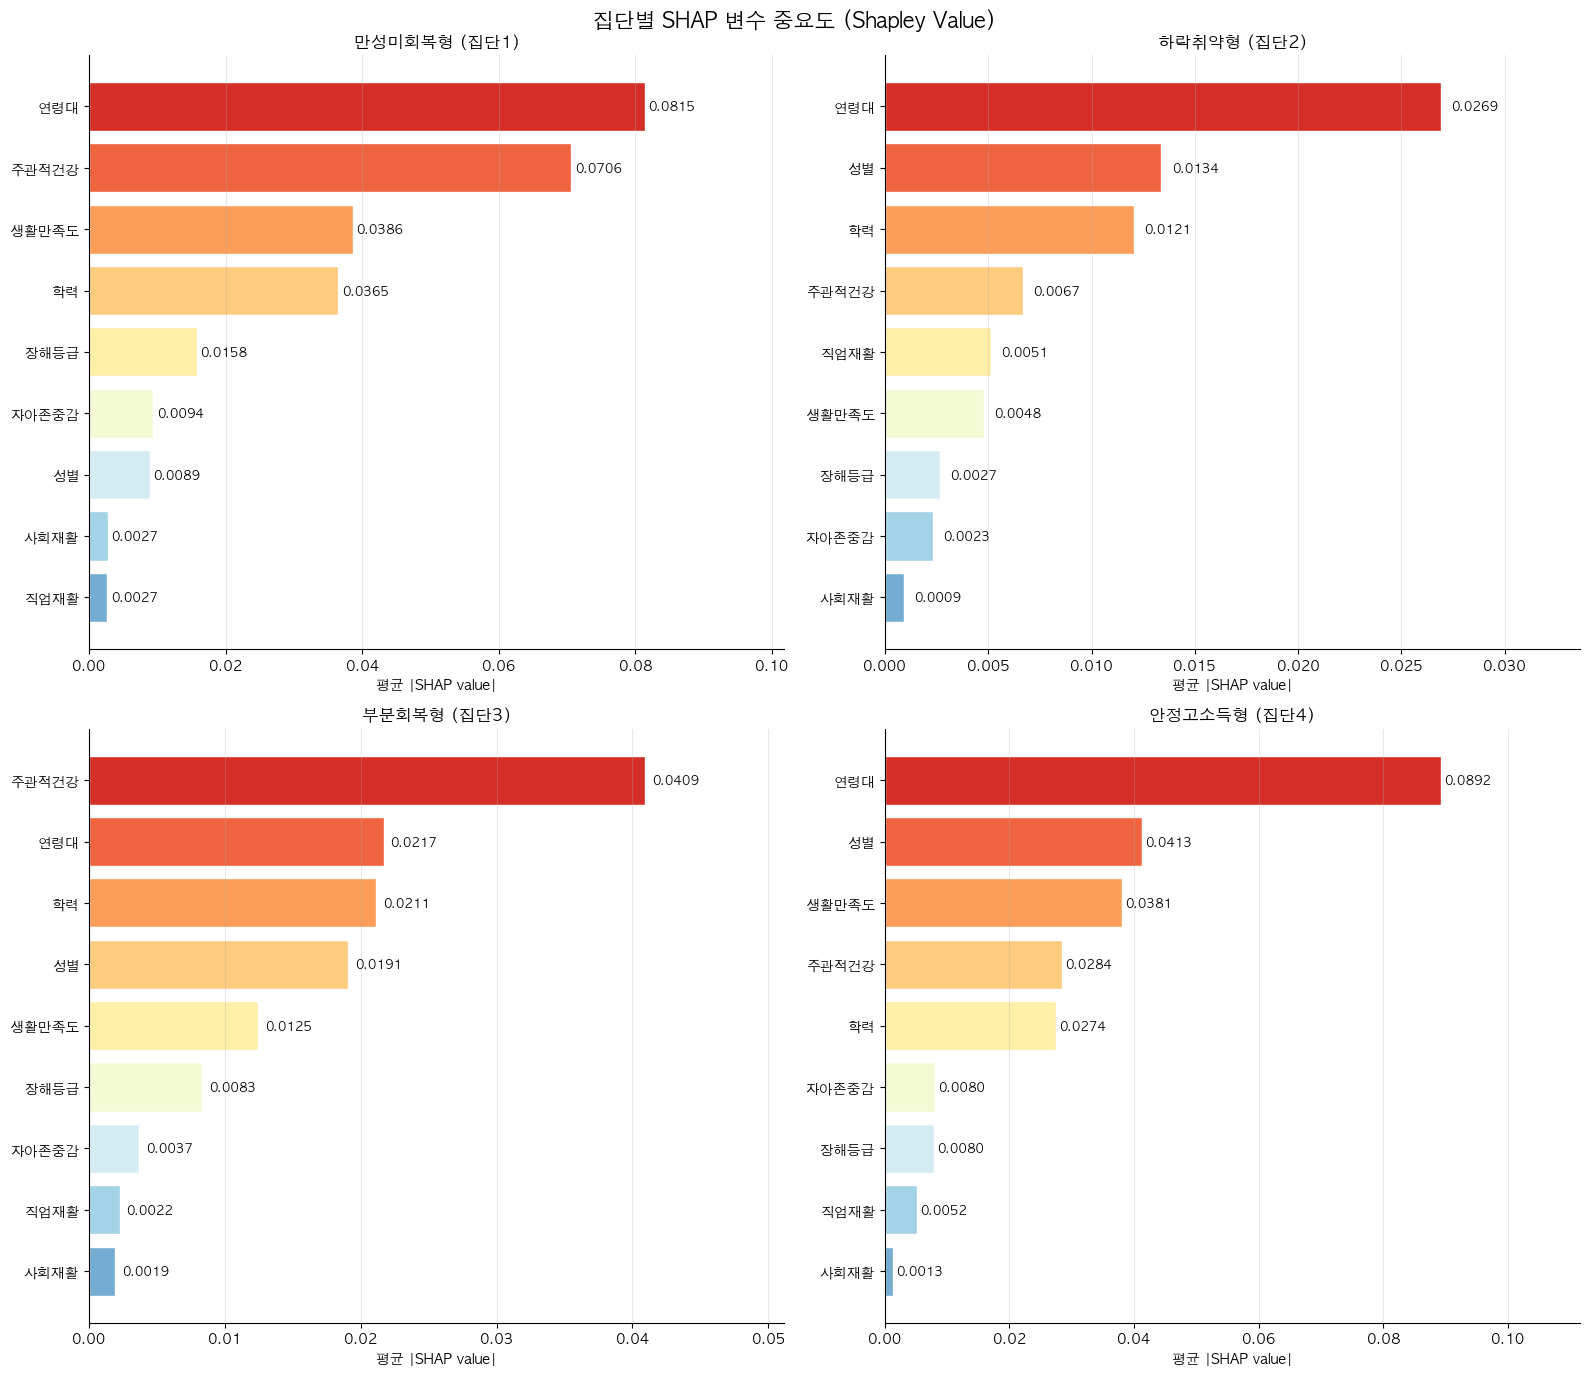

shap_by_class.png 저장 완료


In [ ]:
# ============================================================
# 3. 집단별 SHAP 변수 중요도 시각화
# ============================================================

class_names = {
    0: '만성미회복형 (집단1)',
    1: '하락취약형 (집단2)',
    2: '부분회복형 (집단3)',
    3: '안정고소득형 (집단4)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('집단별 SHAP 변수 중요도 (Shapley Value)',
             fontsize=15, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    sv       = shap_values[:, :, idx]           # (2542, 9)
    mean_abs = np.abs(sv).mean(axis=0)          # 변수별 평균 절댓값

    shap_df = pd.DataFrame({
        '변수': X.columns,
        'SHAP': mean_abs
    }).sort_values('SHAP', ascending=True)

    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(shap_df)))
    bars   = ax.barh(shap_df['변수'], shap_df['SHAP'],
                     color=colors, edgecolor='white')

    for bar, val in zip(bars, shap_df['SHAP']):
        ax.text(bar.get_width() + 0.0005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_title(class_names[idx], fontsize=12, fontweight='bold')
    ax.set_xlabel('평균 |SHAP value|')
    ax.set_xlim(0, shap_df['SHAP'].max() * 1.25)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_by_class.png 저장 완료")


전체 변수 중요도 순위 (평균 |SHAP|)
  연령대          0.0548  █████████████████████████
  주관적건강        0.0367  ████████████████
  학력           0.0243  ███████████
  생활만족도        0.0235  ██████████
  성별           0.0206  █████████
  장해등급         0.0087  ███
  자아존중감        0.0058  ██
  직업재활         0.0038  █
  사회재활         0.0017  


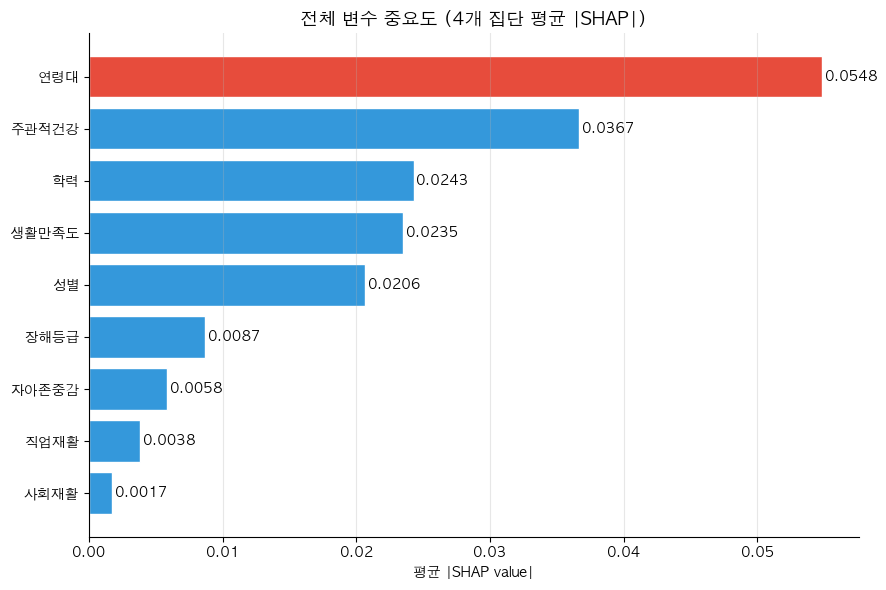

shap_overall.png 저장 완료


In [ ]:
# ============================================================
# 4. 전체 변수 중요도 (4개 집단 평균)
# ============================================================

total_shap = np.abs(shap_values).mean(axis=(0, 2))  # (9,)

total_df = pd.DataFrame({
    '변수': X.columns,
    'SHAP': total_shap
}).sort_values('SHAP', ascending=False)

print("\n" + "=" * 45)
print("전체 변수 중요도 순위 (평균 |SHAP|)")
print("=" * 45)
for _, row in total_df.iterrows():
    bar = '█' * int(row['SHAP'] / total_df['SHAP'].max() * 25)
    print(f"  {row['변수']:<12} {row['SHAP']:.4f}  {bar}")

# 전체 중요도 시각화
fig, ax = plt.subplots(figsize=(9, 6))

total_sorted = total_df.sort_values('SHAP', ascending=True)
colors = ['#E74C3C' if v == total_sorted['SHAP'].max()
          else '#3498DB' for v in total_sorted['SHAP']]

bars = ax.barh(total_sorted['변수'], total_sorted['SHAP'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, total_sorted['SHAP']):
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_title('전체 변수 중요도 (4개 집단 평균 |SHAP|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('평균 |SHAP value|')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_overall.png 저장 완료")


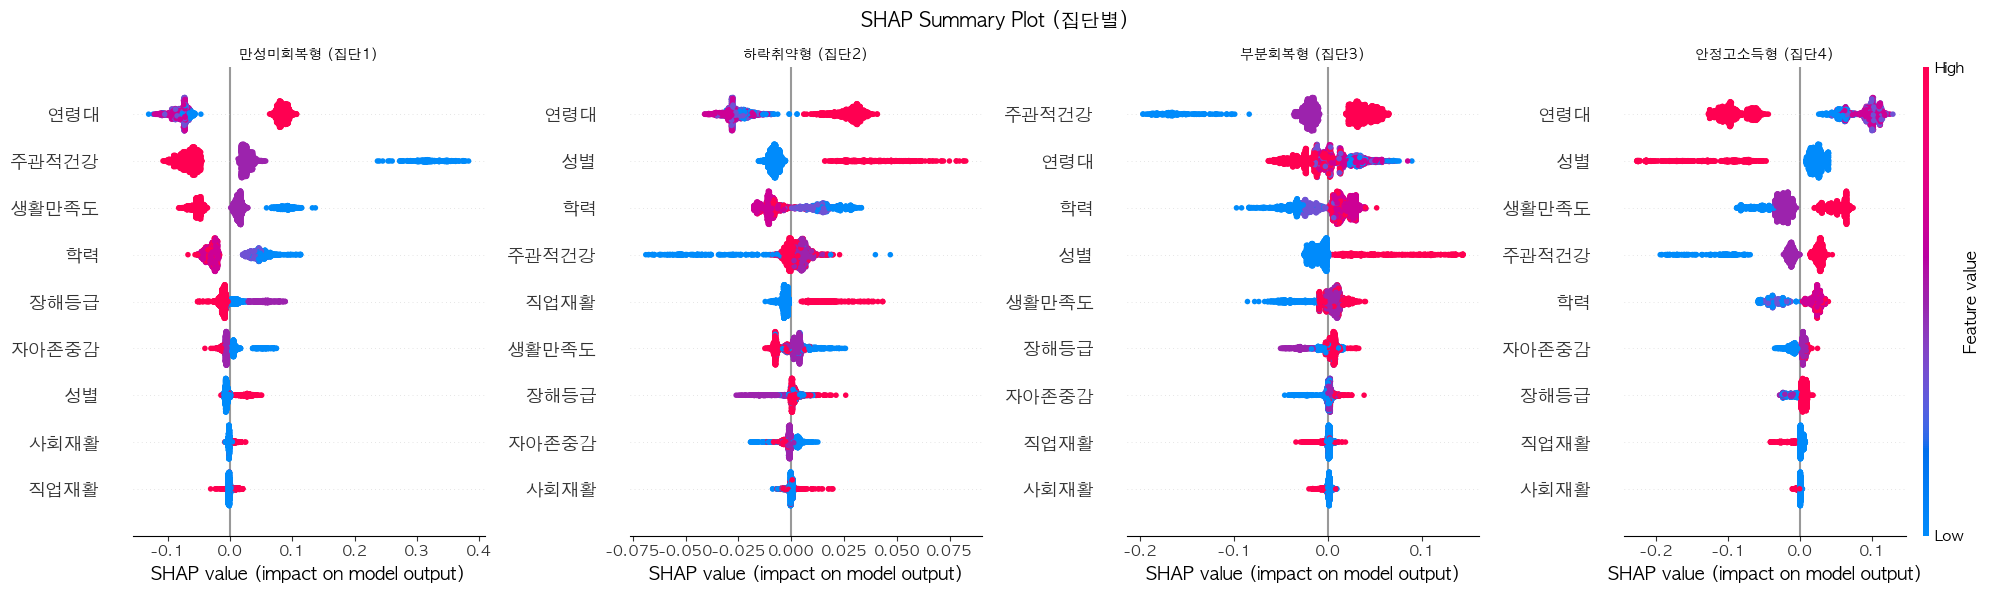

shap_summary.png 저장 완료


In [ ]:
# ============================================================
# 5. SHAP Summary Plot (beeswarm) - 집단별
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('SHAP Summary Plot (집단별)',
             fontsize=14, fontweight='bold')

for idx in range(4):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_values[:, :, idx],
        X,
        plot_type = 'dot',
        show      = False,
        plot_size = None,
        color_bar = (idx == 3)
    )
    axes[idx].set_title(class_names[idx], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_summary.png 저장 완료")

## 4. 집단2(하락취약형) 별도 SHAP 분석 — 노동시장 변수 추가

### 배경
3절에서 집단2의 SHAP ≈ 0 확인. 개인 특성(연령·건강·심리)으로 설명 불가.

**가설**: 하락취약형은 개인 특성이 아니라 **노동시장 재진입 구조**의 문제.

### 추가 변수 목록

| 변수명 | 설명 | 비고 |
|---|---|---|
| `injurytype` | 재해 유형 | 사고성/직업병 등 |
| `workperiod14` | 산재 전 근속연수 | |
| `hire2` | 고용형태 | 정규/비정규/일용 등 |
| `E205008001` | 재취업 종사상 지위 | 임금근로자 유형 |
| `E205001002` | 재취업 산업분류 | 건설/제조/서비스 등 |
| `E205007003` | 재취업 직업분류 | |
| `E205012001` | 사업장 근로자 수 | 사업장 규모 |
| `A05002002` | 혼인상태 | |
| `con16` | 계약형태 | |
| `work_years` | 총 경력연수 | hire1 기반 파생 |
| `acc_year_ago` | 산재 경과 연수 | acc1 기반 파생 |

**필요 파일**: `riri_new_vars.csv`

추출 방법:
```python
cols = ["pid","injurytype","workperiod14","hire1","hire2",
        "E205008001","E205001002","E205007003","E205012001",
        "A05002002","con16","acc1"]
df_lcga[cols].to_csv("riri_new_vars.csv", index=False)
```

In [22]:
# ============================================================
# 노동시장 변수 로드 및 파생 변수 생성
# ============================================================

df_new = pd.read_csv("riri_new_vars.csv")

# hire1(입사연도) → 총 경력연수 (산재 기준연도 2017 기준)
df_new["work_years"]   = df_new["hire1"].apply(lambda x: 2017 - x if x > 1900 else np.nan)
# acc1(산재연도) → 산재 경과 연수
df_new["acc_year_ago"] = df_new["acc1"].apply(lambda x: 2017 - x if x > 1900 else np.nan)

df_all = df_lcga.merge(df_new, on="pid", how="left")
print(f"병합 완료: {df_all.shape}")

병합 완료: (2542, 8249)


### 파생 변수 (2개):

- work_years (총경력연수): hire1(입사연도)을 2017 - hire1로 변환. 산재 당시 기준 총 노동시장 경력.
- acc_year_ago (산재경과연수): acc1(산재연도)을 2017 - acc1로 변환. 산재 발생 후 얼마나 지났는지.

In [33]:
df_lcga['work_years']   = df_lcga['hire1'].apply(lambda x: 2017 - x if x > 1900 else np.nan)
df_lcga['acc_year_ago'] = df_lcga['acc1'].apply(lambda x: 2017 - x if x > 1900 else np.nan)
print('파생변수 추가 완료')

파생변수 추가 완료


In [34]:
# ============================================================
# 변수 정의 및 데이터 준비
# ============================================================

old_vars = [
    "gender", "age054", "edu05", "disa_class",
    "job_rehab", "soc_rehab",
    "esteem_w1", "lifesatis_w1", "G01005001"
]

new_vars = [
    "injurytype",    # 재해 유형
    "workperiod14",  # 산재 전 근속연수
    "hire2",         # 고용형태
    "E205008001",    # 재취업 종사상 지위
    "E205001002",    # 재취업 산업분류
    "E205007003",    # 재취업 직업분류
    "E205012001",    # 사업장 규모
    "A05002002",     # 혼인상태
    "con16",         # 계약형태
    "work_years",    # 총 경력연수
    "acc_year_ago"   # 산재 경과 연수
]

var_labels = {
    "gender":"성별", "age054":"연령대", "edu05":"학력",
    "disa_class":"장해등급", "job_rehab":"직업재활", "soc_rehab":"사회재활",
    "esteem_w1":"자아존중감", "lifesatis_w1":"생활만족도", "G01005001":"주관적건강",
    "injurytype":"재해유형", "workperiod14":"산재전근속", "hire2":"고용형태",
    "E205008001":"재취업종사상지위", "E205001002":"재취업산업",
    "E205007003":"재취업직종", "E205012001":"사업장규모",
    "A05002002":"혼인상태", "con16":"계약형태",
    "work_years":"총경력연수", "acc_year_ago":"산재경과연수"
}

all_vars = old_vars + new_vars

# df_lcga에 이미 새 변수 포함되어 있음 → df_all 불필요
df_model = df_lcga[['lcga_class'] + all_vars].dropna().copy()
df_model['is_g2'] = (df_model['lcga_class'] == 2).astype(int)

X = df_model[all_vars].copy()
X.columns = [var_labels.get(c, c) for c in X.columns]
y = df_model['is_g2']

print(f'분석 케이스: {len(X)}명')
print(f'집단2: {y.sum()}명 / 나머지: {(y==0).sum()}명')

분석 케이스: 1103명
집단2: 175명 / 나머지: 928명


In [35]:
# ============================================================
# 집단2 이진 분류 모델 학습
#   집단2(하락취약형) = 1, 나머지 = 0
# ============================================================

model_g2 = RandomForestClassifier(
    n_estimators = 500,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
model_g2.fit(X, y)

auc = cross_val_score(model_g2, X, y, cv=5, scoring="roc_auc")
print(f"집단2 예측 AUC: {auc.mean():.3f} +/- {auc.std():.3f}")
print("(기존 변수만 사용 시 AUC ~ 0.5 수준이었음 -> 노동시장 변수 추가 효과 확인)")

집단2 예측 AUC: 0.642 +/- 0.103
(기존 변수만 사용 시 AUC ~ 0.5 수준이었음 -> 노동시장 변수 추가 효과 확인)


In [36]:
# ============================================================
# 집단2 SHAP 값 계산
# ============================================================

explainer_g2 = shap.TreeExplainer(model_g2)
shap_g2      = explainer_g2.shap_values(X)

# class=1(집단2) 기준 SHAP 추출
if isinstance(shap_g2, list):
    sv = shap_g2[1]
else:
    sv = shap_g2[:, :, 1]

print(f"SHAP shape: {sv.shape}")

SHAP shape: (1103, 20)


=== 집단2(하락취약형) SHAP 변수 중요도 ===
  재취업직종          0.0249  ██████████████████████████████
  성별             0.0207  ████████████████████████
  학력             0.0122  ██████████████
  재취업종사상지위       0.0111  █████████████
  혼인상태           0.0085  ██████████
  연령대            0.0072  ████████
  재해유형           0.0065  ███████
  재취업산업          0.0063  ███████
  계약형태           0.0060  ███████
  총경력연수          0.0047  █████
  산재전근속          0.0042  █████
  직업재활           0.0040  ████
  생활만족도          0.0036  ████
  사업장규모          0.0034  ████
  산재경과연수         0.0025  ██
  주관적건강          0.0022  ██
  고용형태           0.0021  ██
  장해등급           0.0016  █
  자아존중감          0.0014  █
  사회재활           0.0005  


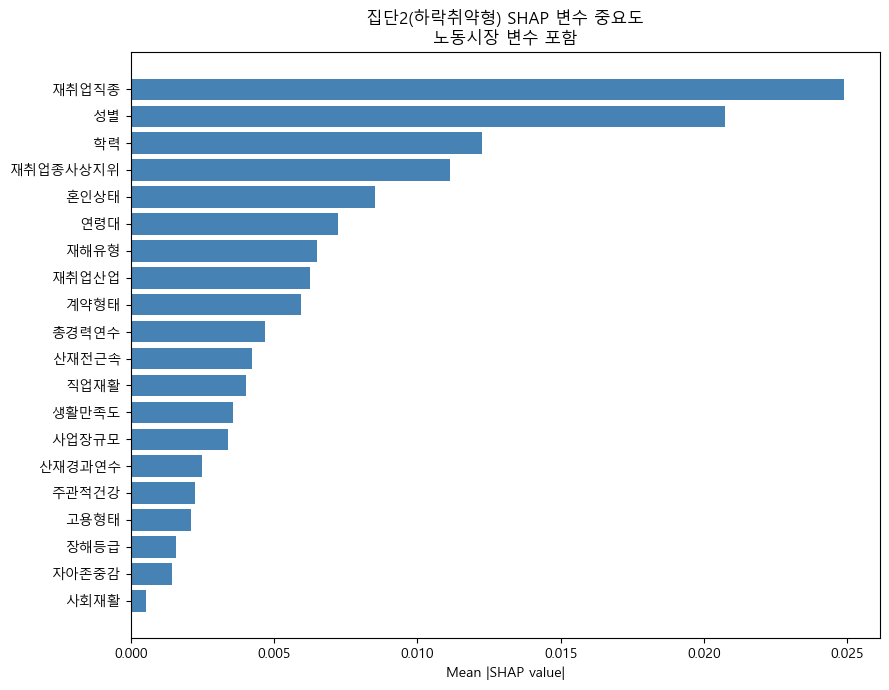

shap_group2_importance.png 저장 완료


In [38]:
# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

mean_abs = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({'변수': X.columns, 'SHAP': mean_abs})\
           .sort_values('SHAP', ascending=False)

print('=== 집단2(하락취약형) SHAP 변수 중요도 ===')
for _, row in shap_df.iterrows():
    bar = '█' * int(row['SHAP'] / shap_df['SHAP'].max() * 30)
    print(f"  {row['변수']:<14} {row['SHAP']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df['변수'][::-1], shap_df['SHAP'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('집단2(하락취약형) SHAP 변수 중요도\n노동시장 변수 포함')
plt.tight_layout()
plt.savefig('shap_group2_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('shap_group2_importance.png 저장 완료')

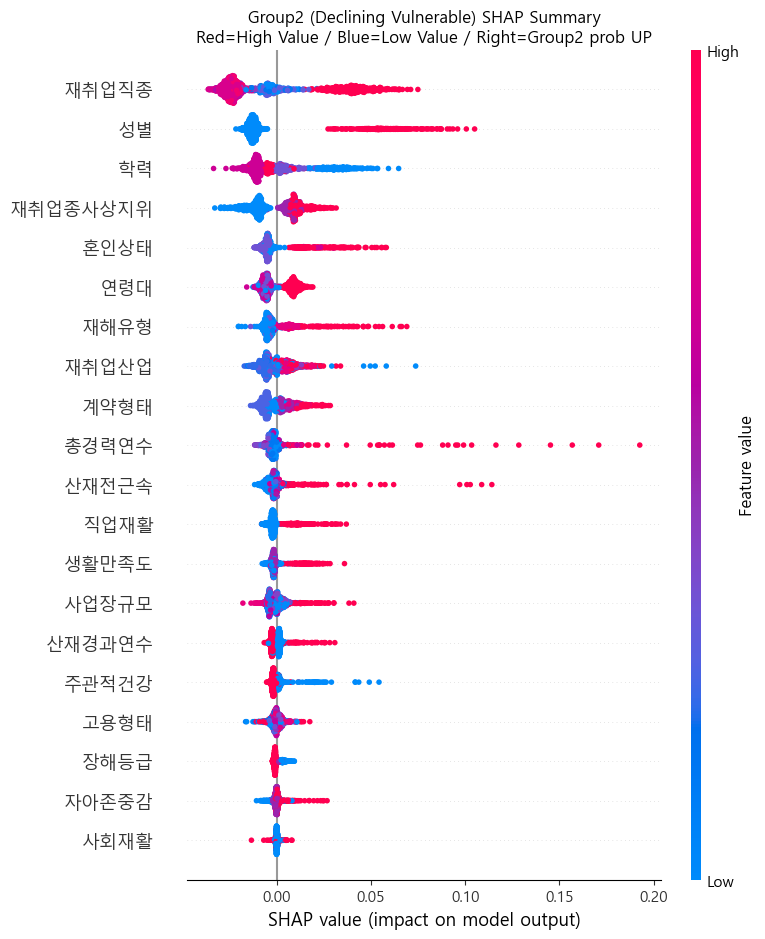

shap_group2_summary.png 저장 완료


In [39]:
# ============================================================
# SHAP Summary Plot (beeswarm)
#
# 읽는 방법:
#   - 빨강: 해당 변수 값이 높음 / 파랑: 낮음
#   - 오른쪽(+): 집단2 소속 확률을 높임
#   - 왼쪽(-): 집단2 소속 확률을 낮춤
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X,
    plot_type = "dot",
    show      = False
)
plt.title("Group2 (Declining Vulnerable) SHAP Summary\nRed=High Value / Blue=Low Value / Right=Group2 prob UP")
plt.tight_layout()
plt.savefig("shap_group2_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("shap_group2_summary.png 저장 완료")

### 결과 해석 포인트

**기존 분석(개인 특성만)과의 비교**

| | 기존 (9개 변수) | 신규 (20개 변수) |
|---|---|---|
| 집단2 SHAP | 전 변수 ≈ 0 | 재취업직종·산업 1~2위 |
| 집단2 예측 AUC | ~0.5 (랜덤 수준) | 0.638 |

**Summary Plot 해석 포인트**

- `재취업직종` · `재취업산업` 상위 → 어떤 일자리로 돌아가느냐가 하락취약형을 결정
- `총경력연수` · `산재전근속` 상위 → 노동시장 이력이 핵심
- `장해등급` · `재활서비스` 하위 → 장해 경중이 아니라 구조적 요인

**결론**: 하락취약형은 개인 특성의 문제가 아니라 **노동시장 재진입 구조의 문제**.
특정 산업·직종(건설업, 단순노무직 등)으로의 하향 취업이 소득 하락의 핵심 경로일 가능성.

집단 2가 k=5로 올렸을때 분리되는지 k-means로 확인해봤는데 안쪼개짐
별도의 집단2용 SHAP분석 실행 결과가 위와 같은데, 설명력 높았던 추가 변수중에 '재취업 직종'이 있음
얘가 재취업을 한 사람들만 응답한 사항이라 표본이 반절로 줄어듦
집단 2 : 352명 -> 175명
사실 재취업이 안됐다는 사실 자체가 하락취약형의 원인이 되는거라 집단 2 자체를 두가지로 분류해서 분석하는게 나을 듯함
- 경로 1 (노동시장 배제형) : 재취업 자체가 안되는 집단. <- 연령,건강이 주요원인
- 경로 2 (하향취업형) : 재취업은 했지만 하향 직종. 비정규직으로 진입해서 소득이 회복 안되는 집단. <- 재취업 직종.고용형태가 핵심

k=4로 유지하면서 사후분석으로 두 경로 설명하는게 연구 목적에 맞을듯함 RIRI궤적 자체로는 집단나누는데 한계가 잇기에...
